# Jaccard Similarity — Trainer/Client Matching Baseline (Semantic Dataset)
**VTC x RMIT AI Project COSC2667**

This notebook applies Jaccard similarity to the semantic dataset.
Unlike the structured dataset which uses clean fixed tags, this dataset has
free-text descriptions for styles, goals and personality traits.

The purpose is the same — establish a baseline score to measure future
semantic/AI models against.

Data source: `semantic_matching__client_trainer_dataset.xlsx`

## Quick explanation of Jaccard similarity

Jaccard similarity just measures the overlap between two sets:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

So if a client wants `{Yoga, Boxing, Strength}` and a trainer offers `{Yoga, Strength, Pilates}`:
- Intersection = `{Yoga, Strength}` → 2 items in common
- Union = `{Yoga, Boxing, Strength, Pilates}` → 4 items total
- Jaccard = 2/4 = **0.5**

Scores go from 0 (nothing in common) to 1 (exact same set).

We run this on three fields — styles, goals, and personality — then combine into one score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Load the data

This dataset has two sheets — clients and trainers.
No title row here so no need for `header=1` unlike the structured dataset.

In [3]:
FILE = 'semantic_matching__client_trainer_dataset.xlsx'

clients  = pd.read_excel(FILE, sheet_name='clients')
trainers = pd.read_excel(FILE, sheet_name='trainers')

print('Clients shape: ', clients.shape)
print('Trainers shape:', trainers.shape)

Clients shape:  (40, 4)
Trainers shape: (40, 5)


In [4]:
clients.head(3)

,client_id,styles_desired,goal_tags,personality_traits
0,C001,"HIIT, circuit workouts, fast-paced sessions","lose weight, get lean, improve body confidence","motivating, upbeat, accountability, energetic"
1,C002,"short intense workouts, metabolic training, ci...","drop body fat, slim down, feel fitter","encouraging, lively, keeps me on track, positive"
2,C003,"conditioning sessions, sweat-focused workouts,...","trim down, feel lighter, improve fitness","pushes me, optimistic, high energy, supportive"


In [5]:
trainers.head(3)

,trainer_id,styles_offered,goal_tags,personality_traits,bio
0,T001,"interval conditioning, metabolic circuits, con...","fat loss, body recomposition, sustainable slim...","high-energy, encouraging, results-driven, acco...",I coach busy adults who want fat loss without ...
1,T002,"high-intensity conditioning, calorie-focused p...","leaning out, physique change, healthier body c...","uplifting, motivational, target-oriented, chec...",My coaching focuses on body recomposition and ...
2,T003,"met-con coaching, fast turnover sessions, endu...","sustainable fat reduction, confidence through ...","driven, positive, keeps clients committed, per...",I help clients reshape their physique with fas...


## Parse columns into sets

Same as the structured notebook — we split comma-separated strings into sets
and lowercase everything.

The difference here is the text is free-form phrases like
`"short intense workouts, metabolic training"` instead of clean tags like `"HIIT"`.
This means fewer exact matches, which is why scores will be lower than the structured baseline.

In [7]:
def to_set(val):
    # handles NaN — return empty set
    if pd.isna(val) or str(val).strip() == '':
        return set()
    return {item.strip().lower() for item in str(val).split(',')}


clients['styles_set']  = clients['styles_desired'].apply(to_set)
clients['goals_set']   = clients['goal_tags'].apply(to_set)
clients['persona_set'] = clients['personality_traits'].apply(to_set)

trainers['styles_set']  = trainers['styles_offered'].apply(to_set)
trainers['goals_set']   = trainers['goal_tags'].apply(to_set)
trainers['persona_set'] = trainers['personality_traits'].apply(to_set)

# sanity check
print('Example client styles:  ', clients.loc[0, 'styles_set'])
print('Example client goals:   ', clients.loc[0, 'goals_set'])
print('Example client persona: ', clients.loc[0, 'persona_set'])

Example client styles:   {'fast-paced sessions', 'circuit workouts', 'hiit'}
Example client goals:    {'get lean', 'lose weight', 'improve body confidence'}
Example client persona:  {'accountability', 'energetic', 'upbeat', 'motivating'}


## No hard filters here

Unlike the structured dataset, this dataset doesn't have approval status,
gender preference or training type columns — so we score all client–trainer
pairs without filtering any out.

## The Jaccard function

In [11]:
def jaccard(set_a, set_b):
    # nothing to compare if both are empty
    if not set_a and not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)


# quick test
a = {'yoga', 'strength', 'boxing'}
b = {'yoga', 'strength', 'pilates'}
print(f'Sets: {a}  vs  {b}')
print(f'Jaccard: {jaccard(a, b):.2f}')  # should be 0.50

Sets: {'boxing', 'strength', 'yoga'}  vs  {'pilates', 'strength', 'yoga'}
Jaccard: 0.50


## Scoring a client–trainer pair

We score three fields — styles, goals, and personality.

This dataset doesn't have per-client priority weights like the structured dataset does,
so we use fixed weights for everyone:
- Style weight: 1.5
- Goal weight: 1.5  
- Persona weight: 0.7 (personality is a softer signal so weighted lower)

Final score = weighted average of all three Jaccard scores.

In [13]:
# fixed weights — same for all clients since no priority columns in this dataset
W_STYLE  = 1.5
W_GOAL   = 1.5
W_PERSONA = 0.7


def score_match(client_row, trainer_row):
    j_styles  = jaccard(client_row['styles_set'],  trainer_row['styles_set'])
    j_goals   = jaccard(client_row['goals_set'],   trainer_row['goals_set'])
    j_persona = jaccard(client_row['persona_set'], trainer_row['persona_set'])

    total_weight = W_STYLE + W_GOAL + W_PERSONA
    score = (W_STYLE * j_styles + W_GOAL * j_goals + W_PERSONA * j_persona) / total_weight

    return {
        'client_id'    : client_row['client_id'],
        'trainer_id'   : trainer_row['trainer_id'],
        'j_styles'     : round(j_styles,  4),
        'j_goals'      : round(j_goals,   4),
        'j_persona'    : round(j_persona, 4),
        'final_score'  : round(score,     4)
    }

## Run all pairs

In [19]:
results = []

for _, client in clients.iterrows():
    for _, trainer in trainers.iterrows():
        results.append(score_match(client, trainer))

scores_df = pd.DataFrame(results)

print(f'Total pairs scored: {len(scores_df)}')
print()
scores_df.head()

Total pairs scored: 1600



,client_id,trainer_id,j_styles,j_goals,j_persona,final_score
0,C001,T001,0.0,0.0,0.0000,0.000
1,C001,T002,0.0,0.0,0.0000,0.000
2,C001,T003,0.0,0.0,0.0000,0.000
3,C001,T004,0.0,0.0,0.1429,0.027
4,C001,T005,0.0,0.0,0.0000,0.000


## Top-N recommendations per client

In [23]:
TOP_N = 5

top_matches = (
    scores_df
    .sort_values('final_score', ascending=False)
    .groupby('client_id')
    .head(TOP_N)
    .reset_index(drop=True)
)

top_matches['rank'] = top_matches.groupby('client_id').cumcount() + 1

top_matches[['client_id', 'rank', 'trainer_id', 'j_styles', 'j_goals', 'j_persona', 'final_score']].head(10)

,client_id,rank,trainer_id,j_styles,j_goals,j_persona,final_score
0,C022,1,T021,0.2,0.0,1.0000,0.2703
1,C030,1,T029,0.0,0.0,0.6000,0.1135
2,C033,1,T034,0.0,0.0,0.6000,0.1135
3,C012,1,T009,0.2,0.0,0.1429,0.1081
4,C034,1,T033,0.2,0.0,0.1429,0.1081
5,C036,1,T030,0.2,0.0,0.0000,0.0811
6,C039,1,T038,0.2,0.0,0.0000,0.0811
7,C011,1,T011,0.0,0.0,0.3333,0.0631
8,C030,2,T033,0.0,0.0,0.3333,0.0631
9,C040,1,T038,0.0,0.0,0.3333,0.0631


In [26]:
# readable view for a specific client
def show_matches(client_id):
    c = clients[clients['client_id'] == client_id].iloc[0]
    print(f"{client_id}")
    print(f"  Styles:   {c['styles_desired']}")
    print(f"  Goals:    {c['goal_tags']}")
    print(f"  Persona:  {c['personality_traits']}")
    print()

    matches = top_matches[top_matches['client_id'] == client_id]
    for _, row in matches.iterrows():
        t = trainers[trainers['trainer_id'] == row['trainer_id']].iloc[0]
        print(f"  #{int(row['rank'])}  {row['trainer_id']}")
        print(f"       Offers:  {t['styles_offered']}")
        print(f"       Goals:   {t['goal_tags']}")
        print(f"       Persona: {t['personality_traits']}")
        print(f"       Style={row['j_styles']:.2f}  Goal={row['j_goals']:.2f}  Persona={row['j_persona']:.2f}  Score={row['final_score']:.2f}")
        print()


show_matches('C001')

C001
  Styles:   HIIT, circuit workouts, fast-paced sessions
  Goals:    lose weight, get lean, improve body confidence
  Persona:  motivating, upbeat, accountability, energetic

  #1  T040
       Offers:  boxing skill progressions, technical striking sessions, reaction drills
       Goals:   reaction speed development, combat-inspired conditioning, self-belief building
       Persona: commanding, upbeat, energetic, fun
       Style=0.00  Goal=0.00  Persona=0.33  Score=0.06

  #2  T018
       Offers:  field-based conditioning, acceleration mechanics, jump development
       Goals:   athletic conditioning, speed enhancement, force production
       Persona: high-expectation, direct, energetic, competitive
       Style=0.00  Goal=0.00  Persona=0.14  Score=0.03

  #3  T038
       Offers:  coordination drills, striking fundamentals, bag-and-mitt work
       Goals:   skill-based fat loss, sharper reactions, stress relief training
       Persona: charismatic, motivating, sharp, encouraging
 

In [28]:
show_matches('C002')

C002
  Styles:   short intense workouts, metabolic training, circuits
  Goals:    drop body fat, slim down, feel fitter
  Persona:  encouraging, lively, keeps me on track, positive

  #1  T009
       Offers:  foundational movement coaching, step-by-step training, approachable fitness
       Goals:   general wellness, habit formation, lifestyle change
       Persona: empathetic, calm, approachable, encouraging
       Style=0.00  Goal=0.00  Persona=0.14  Score=0.03

  #2  T038
       Offers:  coordination drills, striking fundamentals, bag-and-mitt work
       Goals:   skill-based fat loss, sharper reactions, stress relief training
       Persona: charismatic, motivating, sharp, encouraging
       Style=0.00  Goal=0.00  Persona=0.14  Score=0.03

  #3  T039
       Offers:  combat movement coaching, footwork development, conditioning rounds
       Goals:   fight-style fitness, coordination improvement, empowerment through striking
       Persona: strong presence, lively, empowering, demand

## Visualisations

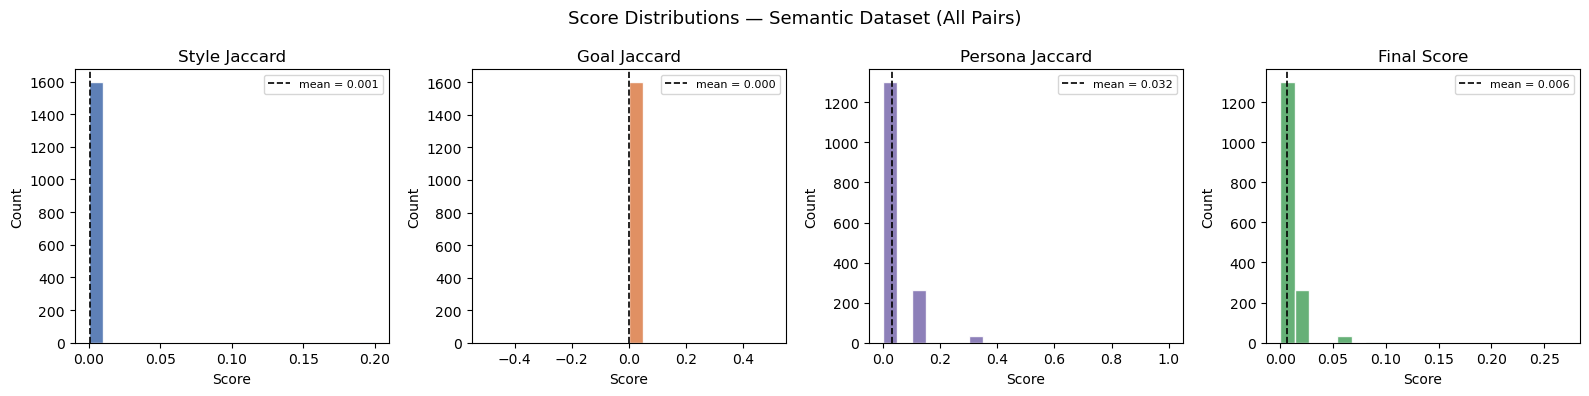

In [31]:
# score distributions across all pairs
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Score Distributions — Semantic Dataset (All Pairs)', fontsize=13)

cols   = ['j_styles', 'j_goals', 'j_persona', 'final_score']
titles = ['Style Jaccard', 'Goal Jaccard', 'Persona Jaccard', 'Final Score']
colors = ['#4C72B0', '#DD8452', '#8172B2', '#55A868']

for ax, col, title, color in zip(axes, cols, titles, colors):
    ax.hist(scores_df[col], bins=20, color=color, edgecolor='white', alpha=0.9)
    ax.axvline(scores_df[col].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean = {scores_df[col].mean():.3f}')
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('semantic_score_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

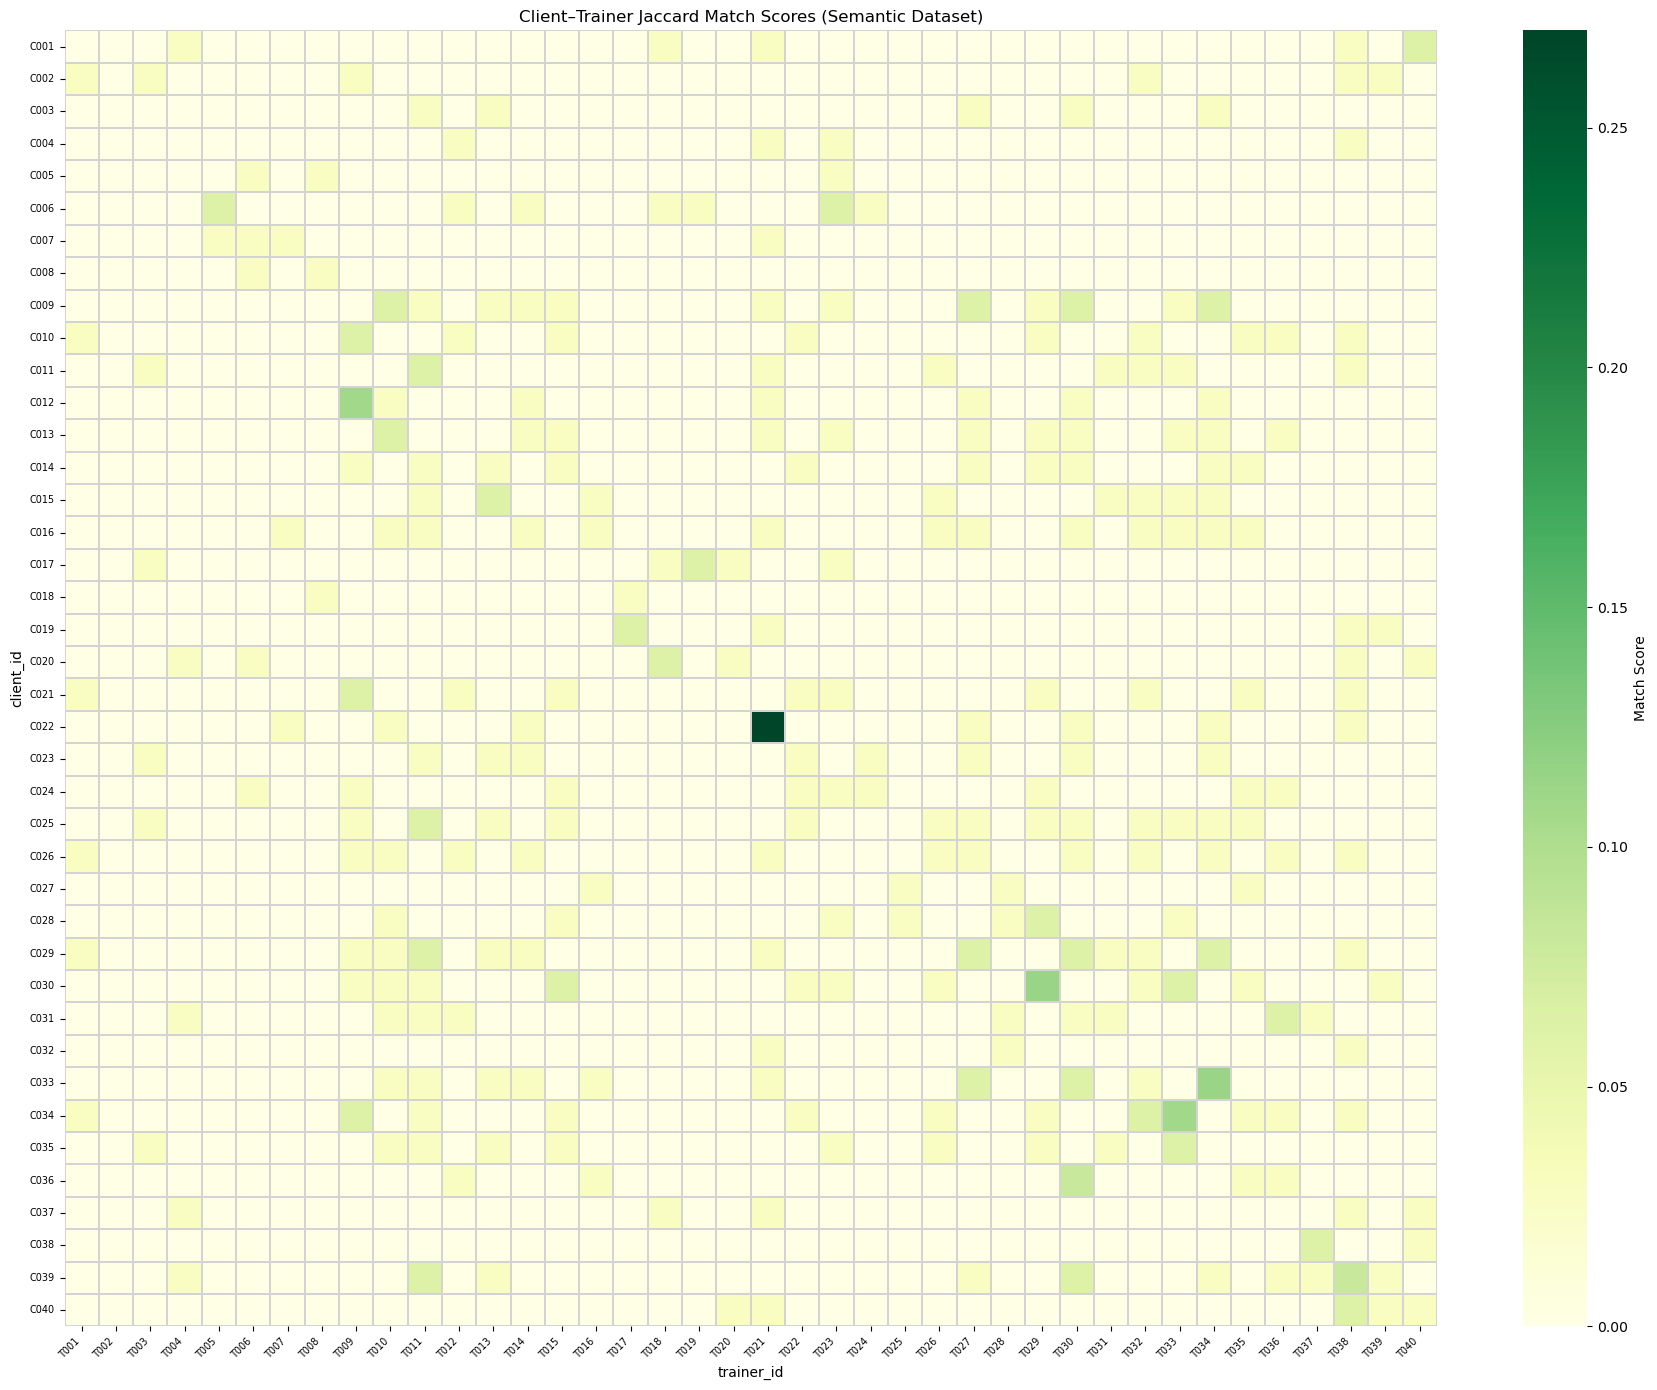

In [32]:
# heatmap — 40x40 so we keep annotation off for readability
matrix = scores_df.pivot(index='client_id', columns='trainer_id', values='final_score')

plt.figure(figsize=(18, 14))
sns.heatmap(
    matrix,
    cmap='YlGn',
    annot=False,
    linewidths=0.1,
    linecolor='lightgrey',
    cbar_kws={'label': 'Match Score'}
)
plt.title('Client–Trainer Jaccard Match Scores (Semantic Dataset)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('semantic_match_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

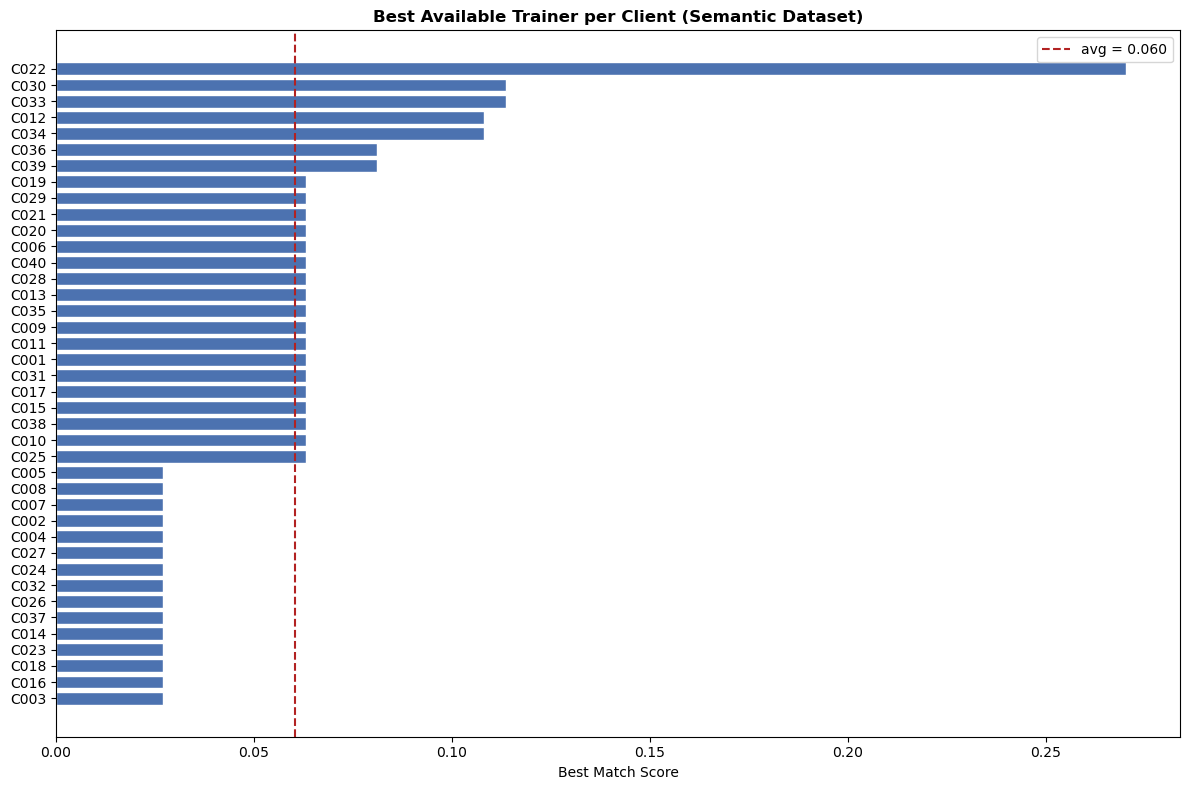

In [33]:
# best match per client
best_per_client = (
    top_matches[top_matches['rank'] == 1]
    .set_index('client_id')['final_score']
    .sort_values()
)

plt.figure(figsize=(12, 8))
plt.barh(best_per_client.index, best_per_client.values, color='#4C72B0', edgecolor='white')
plt.axvline(best_per_client.mean(), color='firebrick', linestyle='--', linewidth=1.5,
            label=f'avg = {best_per_client.mean():.3f}')
plt.xlabel('Best Match Score')
plt.title('Best Available Trainer per Client (Semantic Dataset)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('semantic_best_match_per_client.png', dpi=120, bbox_inches='tight')
plt.show()

## Baseline summary

In [35]:
top1 = top_matches[top_matches['rank'] == 1]['final_score']

print('=== Jaccard Baseline Summary (Semantic Dataset) ===')
print(f'  Clients: {len(clients)}   Trainers: {len(trainers)}')
print(f'  Total pairs scored: {len(scores_df)}')
print()
print('  All pairs:')
print(f'    avg score : {scores_df["final_score"].mean():.4f}')
print(f'    median    : {scores_df["final_score"].median():.4f}')
print(f'    max       : {scores_df["final_score"].max():.4f}')
print(f'    std       : {scores_df["final_score"].std():.4f}')
print()
print('  Best match per client:')
print(f'    avg       : {top1.mean():.4f}')
print(f'    median    : {top1.median():.4f}')
print(f'    score > 0.1 : {(top1 > 0.1).sum()} clients')
print(f'    score = 0.0 : {(top1 == 0).sum()} clients')
print()
print('  Note: scores are lower than structured dataset because free-text')
print('  descriptions rarely share exact words — this is expected and')
print('  motivates the use of semantic/embedding models.')

=== Jaccard Baseline Summary (Semantic Dataset) ===
  Clients: 40   Trainers: 40
  Total pairs scored: 1600

  All pairs:
    avg score : 0.0063
    median    : 0.0000
    max       : 0.2703
    std       : 0.0157

  Best match per client:
    avg       : 0.0604
    median    : 0.0631
    score > 0.1 : 5 clients
    score = 0.0 : 0 clients

  Note: scores are lower than structured dataset because free-text
  descriptions rarely share exact words — this is expected and
  motivates the use of semantic/embedding models.


In [36]:
# export
scores_df.to_csv('jaccard_semantic_all_scores.csv', index=False)
top_matches.to_csv('jaccard_semantic_top_matches.csv', index=False)

print('Saved: jaccard_semantic_all_scores.csv, jaccard_semantic_top_matches.csv')

Saved: jaccard_semantic_all_scores.csv, jaccard_semantic_top_matches.csv


## Why scores are low here vs the structured dataset

The structured dataset uses fixed tags like `"HIIT"`, `"weight_loss"` — exact words that
match directly. Jaccard handles that well.

This dataset uses free-text like `"short intense workouts"` vs `"interval conditioning"`.
They mean the same thing but share zero words — so Jaccard scores them as 0.

That gap is exactly what semantic similarity (TF-IDF, embeddings) is designed to fix.
This low baseline score is the evidence that justifies moving to a smarter model.